# 🎓 THESIS PROJECT: VISUAL ANOMALY DETECTION
## NOTEBOOK 2: CONVOLUTIONAL AUTOENCODER OPTIMIZATION & CONTROLLED TUNING

### Objective
This notebook extends the controlled baseline established in Notebook 1 by evaluating whether a deeper convolutional autoencoder and a small, predefined training hyperparameter search improve reconstruction-based anomaly detection.

The notebook deliberately preserves the same dataset, image preprocessing, outer train/validation split, label semantics and anomaly-score direction used in Notebook 1.

### Experimental contract
- **Training data:** only normal (`good`) training images are used to fit candidate models.
- **Development validation:** the normal validation pool inherited from the Notebook 1 split is partitioned into:
  - a **tuning-validation subset** used for early stopping, learning-rate scheduling and hyperparameter selection;
  - an independent **calibration subset** used only after model selection to determine the operational threshold.
- **Testing:** final MVTec test images are not used for fitting, hyperparameter selection, early stopping, learning-rate scheduling or threshold calibration.
- **Label contract:** `0 = good`, `1 = anomaly`.
- **Score contract:** **higher reconstruction error = more anomalous**.
- **Primary ranking metric:** ROC-AUC from continuous reconstruction-error scores.
- **Optimization criterion:** minimum normal tuning-validation reconstruction MSE.
- **Baseline comparison:** finalized Notebook 1 metrics are imported as a frozen external reference rather than re-trained.

The purpose of Notebook 2 is controlled model development, not final-model selection across the whole thesis. A negative optimization result is retained and reported if the tuned model does not improve the Notebook 1 baseline.


### BLOCK 1: IMPORT LIBRARIES & GLOBAL CONFIGURATION

**OBJECTIVE:**  
Preserve the shared Notebook 1 experiment contract while adding only the components required for controlled autoencoder tuning.

**SHARED WITH NOTEBOOK 1:**
- `IMG_SIZE = (128, 128)`
- `TARGET_CLASS = "bottle"`
- `SEED = 42`
- `NORMAL_LABEL = 0`, `ANOMALY_LABEL = 1`
- `VALIDATION_FRACTION = 0.20`
- `TARGET_VALIDATION_FPR = 0.05`
- deterministic execution
- identical image-loading and normalization semantics

**NOTEBOOK 2 EXTENSIONS:**
- deeper convolutional autoencoder with Batch Normalization;
- `EarlyStopping` and `ReduceLROnPlateau`;
- predefined learning-rate and batch-size grid;
- independent tuning-validation and threshold-calibration subsets.


In [1]:
# ==========================================================================================================================================================
# BLOCK 1: IMPORT LIBRARIES & GLOBAL CONFIGURATION
# ==========================================================================================================================================================

print("INITIALIZING CONTROLLED AUTOENCODER TUNING ENVIRONMENT...\n")
print("ACTION: Loading shared experiment contracts and Notebook 2 tuning components.\n")


# REQUIRED MODULE IMPORTS

import gc
import json
import random
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Input,
    MaxPooling2D,
    UpSampling2D,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import img_to_array, load_img


# SHARED GLOBAL CONFIGURATION — IDENTICAL SEMANTICS TO NOTEBOOK 1

SEED = 42
IMG_SIZE = (128, 128)
TARGET_CLASS = "bottle"

NORMAL_LABEL = 0
ANOMALY_LABEL = 1

VALIDATION_FRACTION = 0.20
TARGET_VALIDATION_FPR = 0.05

IMAGE_EXTENSIONS = {".png"}

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
KAGGLE_WORK_ROOT = Path("/kaggle/working")
KAGGLE_TEMP_ROOT = Path("/kaggle/temp")

PREFERRED_ARCHIVE_NAME = "mvtec_anomaly_detection.tar.xz"


# NOTEBOOK 2 OPTIMIZATION CONFIGURATION

TUNING_VALIDATION_FRACTION = 0.50

LEARNING_RATE_GRID = (1e-3, 1e-4)
BATCH_SIZE_GRID = (16, 8)

MAX_TUNING_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
LR_REDUCTION_PATIENCE = 3
LR_REDUCTION_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6

NOTEBOOK2_ARTIFACT_DIR = KAGGLE_WORK_ROOT / "notebook2_artifacts"
NOTEBOOK2_METRICS_PATH = KAGGLE_WORK_ROOT / "notebook2_metrics.json"

DATASET_TEMP_ROOT = KAGGLE_TEMP_ROOT / "mvtec_ad_notebook2"
TUNING_TEMP_ROOT = KAGGLE_TEMP_ROOT / "notebook2_tuning"

BASELINE_METRICS_FILENAME = "baseline_metrics.json"
EXPECTED_BASELINE_SCHEMA = "2.1"


# REPRODUCIBILITY CONFIGURATION

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()


# CONFIGURATION INTEGRITY CHECKS

if not isinstance(IMG_SIZE, tuple) or len(IMG_SIZE) != 2 or any(int(v) <= 0 for v in IMG_SIZE):
    raise ValueError(
        f"BLOCK 1 CONFIGURATION FAILURE: invalid IMG_SIZE={IMG_SIZE!r}"
    )

if not (0.0 < VALIDATION_FRACTION < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: VALIDATION_FRACTION must be between 0 and 1."
    )

if not (0.0 < TUNING_VALIDATION_FRACTION < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: TUNING_VALIDATION_FRACTION must be between 0 and 1."
    )

if not (0.0 < TARGET_VALIDATION_FPR < 1.0):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: TARGET_VALIDATION_FPR must be between 0 and 1."
    )

if not LEARNING_RATE_GRID or not BATCH_SIZE_GRID:
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: tuning grids must not be empty."
    )

if any((not np.isfinite(value) or value <= 0.0) for value in LEARNING_RATE_GRID):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: all learning rates must be positive and finite."
    )

if any(int(value) <= 0 for value in BATCH_SIZE_GRID):
    raise ValueError(
        "BLOCK 1 CONFIGURATION FAILURE: all batch sizes must be positive integers."
    )


print("CONFIGURATION SUMMARY")
print(f"  Target class               : {TARGET_CLASS}")
print(f"  Image size                 : {IMG_SIZE}")
print(f"  Random seed                : {SEED}")
print(f"  Outer validation fraction  : {VALIDATION_FRACTION:.0%}")
print(f"  Tuning share of val pool   : {TUNING_VALIDATION_FRACTION:.0%}")
print(f"  Target calibration FPR     : {TARGET_VALIDATION_FPR:.0%}")
print(f"  Learning-rate grid         : {LEARNING_RATE_GRID}")
print(f"  Batch-size grid            : {BATCH_SIZE_GRID}")

print("\n✅ BLOCK 1 COMPLETED: Shared and Notebook 2-specific contracts initialized.")


INITIALIZING CONTROLLED AUTOENCODER TUNING ENVIRONMENT...

ACTION: Loading shared experiment contracts and Notebook 2 tuning components.

CONFIGURATION SUMMARY
  Target class               : bottle
  Image size                 : (128, 128)
  Random seed                : 42
  Outer validation fraction  : 20%
  Tuning share of val pool   : 50%
  Target calibration FPR     : 5%
  Learning-rate grid         : (0.001, 0.0001)
  Batch-size grid            : (16, 8)

✅ BLOCK 1 COMPLETED: Shared and Notebook 2-specific contracts initialized.


### BLOCK 2: DATASET DISCOVERY, EXTRACTION & PATH RESOLUTION

**OBJECTIVE:**  
Resolve the same MVTec AD `bottle` dataset used by Notebook 1 while protecting dataset provenance in the Notebook 2 environment.

**WHY THIS BLOCK IS NOT BYTE-FOR-BYTE IDENTICAL TO NOTEBOOK 1:**  
Notebook 2 also mounts the saved output of Notebook 1 in order to read `baseline_metrics.json`. That upstream notebook output may itself contain extracted dataset folders. Notebook 2 therefore explicitly **excludes notebook-output mounts as candidate image-data sources** and prioritizes the independently attached MVTec dataset.

**DISCOVERY STRATEGY:**
1. Reuse a valid temporary extraction created in the current session.
2. Search directly mounted non-notebook Kaggle inputs for the target class.
3. Search non-notebook Kaggle inputs for a compatible MVTec archive.
4. Extract to `/kaggle/temp`, not `/kaggle/working`, so raw dataset copies are not persisted as Notebook 2 artifacts.
5. Validate the final MVTec class structure before continuing.

This changes storage/provenance handling only; the dataset and downstream preprocessing contract remain the same as Notebook 1.


In [2]:
# ==========================================================================================================================================================
# BLOCK 2: DATASET DISCOVERY, EXTRACTION & PATH RESOLUTION
# ==========================================================================================================================================================

print("RESOLVING MVTEC DATASET STRUCTURE...\n")
print("ACTION: Locating the canonical MVTec input while excluding upstream notebook-output copies.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_2_objects = [
    "KAGGLE_INPUT_ROOT",
    "DATASET_TEMP_ROOT",
    "TARGET_CLASS",
    "PREFERRED_ARCHIVE_NAME",
]

_missing_block_2_objects = [
    object_name
    for object_name in _required_block_2_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_2_objects:
    raise RuntimeError(
        "BLOCK 2 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_2_objects}. Run Block 1 first."
    )


# DATASET DISCOVERY HELPERS

def is_valid_mvtec_class_dir(candidate):
    """Return True when a directory satisfies the minimum MVTec class contract."""

    candidate = Path(candidate)

    return (
        candidate.is_dir()
        and (candidate / "train" / "good").is_dir()
        and (candidate / "test" / "good").is_dir()
    )


def find_target_class_dir(search_root):
    """Search one root for the requested MVTec class."""

    search_root = Path(search_root)

    if not search_root.is_dir():
        return None

    direct_candidates = [
        search_root / TARGET_CLASS,
        search_root / "mvtec_anomaly_detection" / TARGET_CLASS,
        search_root / "mvtec_ad" / TARGET_CLASS,
        search_root / "mvtec-ad" / TARGET_CLASS,
    ]

    for candidate in direct_candidates:
        if is_valid_mvtec_class_dir(candidate):
            return candidate

    candidate_dirs = sorted(
        (
            path
            for path in search_root.rglob(TARGET_CLASS)
            if path.is_dir()
        ),
        key=lambda path: (
            len(path.parts),
            str(path),
        ),
    )

    for candidate in candidate_dirs:
        if is_valid_mvtec_class_dir(candidate):
            return candidate

    return None


def raw_kaggle_input_roots():
    """
    Return top-level Kaggle inputs that are not notebook-output mounts.

    Saved Kaggle notebook outputs are mounted under /kaggle/input/notebooks
    in the current workflow and must not become the image-data source.
    """

    if not KAGGLE_INPUT_ROOT.is_dir():
        return []

    return [
        path
        for path in sorted(
            KAGGLE_INPUT_ROOT.iterdir(),
            key=str,
        )
        if path.name != "notebooks"
    ]


def discover_mvtec_archive(search_roots):
    """Return the most plausible MVTec archive from canonical input roots."""

    archives = []

    for search_root in search_roots:

        if not Path(search_root).is_dir():
            continue

        archives.extend(
            path
            for path in Path(search_root).rglob("*.tar.xz")
            if path.is_file()
        )

    archives = sorted(
        set(archives),
        key=str,
    )

    if not archives:
        return None

    def archive_rank(path):

        name = path.name.lower()
        parent_text = str(path.parent).lower()

        exact_name = int(
            name == PREFERRED_ARCHIVE_NAME.lower()
        )

        mentions_mvtec = int(
            "mvtec" in name
            or "mvtec" in parent_text
        )

        mentions_target = int(
            TARGET_CLASS.lower() in name
        )

        return (
            -exact_name,
            -mentions_mvtec,
            -mentions_target,
            len(path.parts),
            str(path),
        )

    return sorted(
        archives,
        key=archive_rank,
    )[0]


# STAGE 1: REUSE TEMPORARY EXTRACTION FROM THIS SESSION

BASE_DIR = find_target_class_dir(
    DATASET_TEMP_ROOT
)

dataset_source = (
    "session_temp"
    if BASE_DIR is not None
    else None
)


# STAGE 2: SEARCH CANONICAL NON-NOTEBOOK INPUTS

raw_input_roots = raw_kaggle_input_roots()

if BASE_DIR is None:

    direct_matches = []

    for search_root in raw_input_roots:

        candidate = find_target_class_dir(
            search_root
        )

        if candidate is not None:
            direct_matches.append(
                candidate
            )

    if direct_matches:

        BASE_DIR = sorted(
            direct_matches,
            key=lambda path: (
                len(path.parts),
                str(path),
            ),
        )[0]

        dataset_source = "canonical_kaggle_input"


# STAGE 3: DISCOVER AND EXTRACT ARCHIVE TO /kaggle/temp

if BASE_DIR is None:

    archive_path = discover_mvtec_archive(
        raw_input_roots
    )

    if archive_path is None:

        mounted_entries = (
            sorted(
                path.name
                for path in KAGGLE_INPUT_ROOT.iterdir()
            )
            if KAGGLE_INPUT_ROOT.is_dir()
            else []
        )

        raise FileNotFoundError(
            "BLOCK 2 DATASET FAILURE: no valid canonical MVTec "
            f"'{TARGET_CLASS}' directory or compatible .tar.xz archive was found "
            "outside notebook-output mounts. "
            f"Mounted input entries: {mounted_entries}. "
            "Attach the MVTec AD dataset independently of the Notebook 1 output."
        )

    DATASET_TEMP_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        f"Discovered dataset archive: {archive_path}"
    )

    print(
        f"Extracting archive to temporary session storage: {DATASET_TEMP_ROOT}\n"
    )

    with tarfile.open(
        archive_path,
        mode="r:*",
    ) as archive:

        archive.extractall(
            DATASET_TEMP_ROOT,
            filter="data",
        )

    BASE_DIR = find_target_class_dir(
        DATASET_TEMP_ROOT
    )

    dataset_source = "canonical_archive_temp_extraction"


# FINAL DATASET CONTRACT VALIDATION

if BASE_DIR is None or not is_valid_mvtec_class_dir(BASE_DIR):
    raise RuntimeError(
        "BLOCK 2 DATASET FAILURE: dataset discovery/extraction completed, "
        f"but a valid '{TARGET_CLASS}' MVTec class structure could not be resolved."
    )


TRAIN_GOOD_DIR = BASE_DIR / "train" / "good"
TEST_DIR = BASE_DIR / "test"
TEST_GOOD_DIR = TEST_DIR / "good"

defect_categories = sorted(
    path.name
    for path in TEST_DIR.iterdir()
    if path.is_dir()
    and path.name != "good"
)

if not defect_categories:
    raise RuntimeError(
        "BLOCK 2 DATASET FAILURE: the resolved test directory contains no defective categories."
    )


print("DATASET RESOLUTION SUMMARY")
print(f"  Source mode       : {dataset_source}")
print(f"  Resolved class dir: {BASE_DIR}")
print(f"  Train/good        : {TRAIN_GOOD_DIR}")
print(f"  Test/good         : {TEST_GOOD_DIR}")
print(f"  Defect categories : {defect_categories}")

print("\n✅ BLOCK 2 COMPLETED: Canonical dataset source resolved and validated.")


RESOLVING MVTEC DATASET STRUCTURE...

ACTION: Locating the canonical MVTec input while excluding upstream notebook-output copies.

Discovered dataset archive: /kaggle/input/datasets/chrysoulatsitsifa/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz
Extracting archive to temporary session storage: /kaggle/temp/mvtec_ad_notebook2

DATASET RESOLUTION SUMMARY
  Source mode       : canonical_archive_temp_extraction
  Resolved class dir: /kaggle/temp/mvtec_ad_notebook2/bottle
  Train/good        : /kaggle/temp/mvtec_ad_notebook2/bottle/train/good
  Test/good         : /kaggle/temp/mvtec_ad_notebook2/bottle/test/good
  Defect categories : ['broken_large', 'broken_small', 'contamination']

✅ BLOCK 2 COMPLETED: Canonical dataset source resolved and validated.


### BLOCK 3: DATA LOADING, VALIDATION & SPLIT DEFINITION

**OBJECTIVE:**  
Create the notebook's data contract once and reuse it consistently across both baselines.

**PIPELINE:**
1. Load RGB `.png` images in sorted filename order.
2. Resize to `IMG_SIZE`.
3. Convert to `float32` and normalize pixel values to `[0, 1]`.
4. Preserve the original defect category for every anomalous test sample.
5. Split the original `train/good` pool into:
   - `train_images`: normal samples used for model fitting.
   - `validation_images`: the same held-out normal development pool as Notebook 1; Notebook 2 partitions this pool in Block 7 into tuning-validation and independent calibration subsets.
6. Construct one final test set with labels `0 = good`, `1 = anomaly`.

**INTEGRITY AUDIT:**  
Shapes, dtypes, finite values, ranges, sample counts, and label/category alignment are checked before training starts. Invalid or empty data causes a hard failure rather than a silent fallback.

In [3]:
# ==========================================================================================================================================================
# BLOCK 3: DATA LOADING, VALIDATION & SPLIT DEFINITION
# ==========================================================================================================================================================

print("EXECUTING DATA INGESTION & VALIDATION PIPELINE...\n")
print("ACTION: Loading images, preserving defect categories and establishing train/validation/test contracts.\n")


def load_image_directory(folder_path):
    """Load one image directory into a deterministic float32 RGB tensor."""

    folder_path = Path(folder_path)

    if not folder_path.is_dir():
        raise FileNotFoundError(f"Image directory does not exist: {folder_path}")

    image_paths = sorted(
        path
        for path in folder_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    if not image_paths:
        raise RuntimeError(f"No supported images found in: {folder_path}")

    images = np.empty(
        (len(image_paths), IMG_SIZE[0], IMG_SIZE[1], 3),
        dtype=np.float32,
    )

    for index, image_path in enumerate(image_paths):
        image = load_img(image_path, target_size=IMG_SIZE, color_mode="rgb")
        image = img_to_array(image).astype(np.float32) / 255.0
        images[index] = image

    return images, [str(path) for path in image_paths]


def validate_image_batch(batch_name, images):
    """Validate tensor schema and numerical range for one image batch."""

    expected_tail = (IMG_SIZE[0], IMG_SIZE[1], 3)

    if not isinstance(images, np.ndarray):
        raise TypeError(f"{batch_name}: expected numpy.ndarray, received {type(images).__name__}.")

    if images.ndim != 4 or tuple(images.shape[1:]) != expected_tail:
        raise ValueError(
            f"{batch_name}: expected shape (N, {expected_tail}), received {images.shape}."
        )

    if len(images) == 0:
        raise ValueError(f"{batch_name}: batch is empty.")

    if images.dtype != np.float32:
        raise TypeError(f"{batch_name}: expected float32, received {images.dtype}.")

    if not np.isfinite(images).all():
        raise ValueError(f"{batch_name}: NaN or infinite values detected.")

    if float(images.min()) < 0.0 or float(images.max()) > 1.0:
        raise ValueError(f"{batch_name}: normalized pixel values must remain inside [0, 1].")


# LOAD NORMAL TRAINING POOL

train_pool_images, train_pool_paths = load_image_directory(TRAIN_GOOD_DIR)
test_good, test_good_paths = load_image_directory(TEST_GOOD_DIR)


# LOAD ALL DEFECT CATEGORIES WHILE PRESERVING CATEGORY IDENTITY

test_bad_batches = []
test_bad_paths = []
test_bad_categories_list = []

dataset_rows = [
    {"split": "train", "category": "good", "samples": len(train_pool_images)},
    {"split": "test", "category": "good", "samples": len(test_good)},
]

for category in defect_categories:

    category_images, category_paths = load_image_directory(TEST_DIR / category)

    test_bad_batches.append(category_images)
    test_bad_paths.extend(category_paths)
    test_bad_categories_list.extend([category] * len(category_images))

    dataset_rows.append(
        {"split": "test", "category": category, "samples": len(category_images)}
    )

test_bad = np.concatenate(test_bad_batches, axis=0).astype(np.float32, copy=False)
test_bad_categories = np.asarray(test_bad_categories_list, dtype=object)


# NORMAL-ONLY TRAIN / VALIDATION SPLIT

train_indices, validation_indices = train_test_split(
    np.arange(len(train_pool_images)),
    test_size=VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
)

train_images = train_pool_images[train_indices]
validation_images = train_pool_images[validation_indices]

train_paths = [train_pool_paths[index] for index in train_indices]
validation_paths = [train_pool_paths[index] for index in validation_indices]


# FINAL TEST CONTRACT

test_images = np.concatenate((test_good, test_bad), axis=0).astype(np.float32, copy=False)

test_labels = np.concatenate(
    (
        np.full(len(test_good), NORMAL_LABEL, dtype=np.int8),
        np.full(len(test_bad), ANOMALY_LABEL, dtype=np.int8),
    )
)

test_categories = np.concatenate(
    (
        np.full(len(test_good), "good", dtype=object),
        test_bad_categories,
    )
)


# DATA INTEGRITY AUDIT

for batch_name, images in {
    "train_images": train_images,
    "validation_images": validation_images,
    "test_good": test_good,
    "test_bad": test_bad,
    "test_images": test_images,
}.items():
    validate_image_batch(batch_name, images)

if len(test_images) != len(test_labels) or len(test_images) != len(test_categories):
    raise RuntimeError("BLOCK 3 CONTRACT FAILURE: test image/label/category lengths are inconsistent.")

if set(np.unique(test_labels)) != {NORMAL_LABEL, ANOMALY_LABEL}:
    raise RuntimeError("BLOCK 3 CONTRACT FAILURE: final test set does not contain both label classes.")


dataset_audit = pd.DataFrame(dataset_rows)
dataset_audit["share_of_split"] = (
    dataset_audit["samples"]
    / dataset_audit.groupby("split")["samples"].transform("sum")
)

split_audit = pd.DataFrame(
    [
        {"data_object": "train_images", "role": "normal-only model fitting", "samples": len(train_images)},
        {"data_object": "validation_images", "role": "reserved normal development-validation pool", "samples": len(validation_images)},
        {"data_object": "test_good", "role": "final normal evaluation", "samples": len(test_good)},
        {"data_object": "test_bad", "role": "final anomaly evaluation", "samples": len(test_bad)},
    ]
)

print("DATASET CATEGORY AUDIT")
display(dataset_audit)

print("\nEXPERIMENT SPLIT AUDIT")
display(split_audit)

print(
    f"\nTensor contract: {IMG_SIZE[0]}x{IMG_SIZE[1]}x3, "
    f"dtype={train_images.dtype}, range=[{train_images.min():.3f}, {train_images.max():.3f}]"
)

print("\n✅ BLOCK 3 COMPLETED: Shared Notebook 1 data contract reproduced; final test data remain isolated from development decisions.")


EXECUTING DATA INGESTION & VALIDATION PIPELINE...

ACTION: Loading images, preserving defect categories and establishing train/validation/test contracts.

DATASET CATEGORY AUDIT


,split,category,samples,share_of_split
0,train,good,209,1.000000
1,test,good,20,0.240964
2,test,broken_large,20,0.240964
3,test,broken_small,22,0.265060
4,test,contamination,21,0.253012



EXPERIMENT SPLIT AUDIT


,data_object,role,samples
0,train_images,normal-only model fitting,167
1,validation_images,reserved normal development-validation pool,42
2,test_good,final normal evaluation,20
3,test_bad,final anomaly evaluation,63



Tensor contract: 128x128x3, dtype=float32, range=[0.098, 1.000]

✅ BLOCK 3 COMPLETED: Shared Notebook 1 data contract reproduced; final test data remain isolated from development decisions.


### BLOCK 4: DEVELOPMENT-DATA SANITY CHECK

**OBJECTIVE:**  
Verify the statistical consistency of the normal development subsets before model fitting, without opening or visualizing the final test set.

**CHECKS:**
- Compare train and validation sample counts.
- Compare normalized pixel mean, standard deviation, minimum, and maximum.
- Verify that both subsets remain finite and within the expected `[0, 1]` normalization range.

No matplotlib visualization is produced in this block. The notebook's visual dataset comparison is intentionally shown **once only**, in Block 8, after both baseline models and their thresholds have already been fixed.


In [4]:
# ==========================================================================================================================================================
# BLOCK 4: DEVELOPMENT-DATA SANITY CHECK
# ==========================================================================================================================================================

print("INITIATING DEVELOPMENT-DATA SANITY CHECK...\n")
print("ACTION: Verifying normal train/validation statistics while keeping final test data unopened for evaluation.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_4_objects = [
    "train_images",
    "validation_images",
]

_missing_block_4_objects = [
    object_name
    for object_name in _required_block_4_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_4_objects:
    raise RuntimeError(
        "BLOCK 4 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_4_objects}. Run the notebook sequentially from Block 1."
    )


# NORMAL DEVELOPMENT STATISTICAL AUDIT

development_summary = pd.DataFrame(
    [
        {
            "subset": "Normal (Train)",
            "samples": int(len(train_images)),
            "mean_pixel": float(train_images.mean()),
            "std_pixel": float(train_images.std()),
            "min_pixel": float(train_images.min()),
            "max_pixel": float(train_images.max()),
        },
        {
            "subset": "Normal (Validation)",
            "samples": int(len(validation_images)),
            "mean_pixel": float(validation_images.mean()),
            "std_pixel": float(validation_images.std()),
            "min_pixel": float(validation_images.min()),
            "max_pixel": float(validation_images.max()),
        },
    ]
)

display(development_summary)


# DEVELOPMENT CONTRACT VALIDATION

for subset_name, subset in {
    "train_images": train_images,
    "validation_images": validation_images,
}.items():

    if subset.ndim != 4 or subset.shape[-1] != 3:
        raise RuntimeError(
            "BLOCK 4 SHAPE FAILURE: "
            f"{subset_name} has invalid shape {subset.shape}; expected [N, H, W, 3]."
        )

    if not np.isfinite(subset).all():
        raise RuntimeError(
            "BLOCK 4 NUMERICAL FAILURE: "
            f"{subset_name} contains non-finite values."
        )

    subset_min = float(subset.min())
    subset_max = float(subset.max())

    if subset_min < 0.0 or subset_max > 1.0:
        raise RuntimeError(
            "BLOCK 4 RANGE FAILURE: "
            f"{subset_name} range is [{subset_min:.6f}, {subset_max:.6f}], expected [0, 1]."
        )


print(
    "\nNOTE: No final-test images are visualized here. "
    "Notebook 2 proceeds from the same development-data integrity check into controlled tuning."
)

print("\n✅ BLOCK 4 COMPLETED: Normal development-data sanity checks passed.")


INITIATING DEVELOPMENT-DATA SANITY CHECK...

ACTION: Verifying normal train/validation statistics while keeping final test data unopened for evaluation.



,subset,samples,mean_pixel,std_pixel,min_pixel,max_pixel
0,Normal (Train),167,0.538412,0.361365,0.098039,1.0
1,Normal (Validation),42,0.539706,0.361141,0.098039,1.0



NOTE: No final-test images are visualized here. Notebook 2 proceeds from the same development-data integrity check into controlled tuning.

✅ BLOCK 4 COMPLETED: Normal development-data sanity checks passed.


### BLOCK 5: NOTEBOOK 1 BASELINE CONTRACT IMPORT & VERIFICATION

**OBJECTIVE:**  
Import the finalized Notebook 1 baseline metrics as a frozen external reference and verify that they belong to the same experiment contract used by Notebook 2.

**WHY THE BASELINES ARE NOT RE-TRAINED HERE:**  
Notebook 1 owns the PCA + One-Class SVM and Simple Autoencoder baseline experiments. Re-training them in Notebook 2 would duplicate computation and could create baseline drift.

**CONTRACT GATES:**
- exact expected schema version;
- target class, image size and random seed;
- label and score semantics;
- dataset sample counts and defect-category counts;
- validation-threshold policy;
- required baseline keys and internal metric consistency.

A contract is accepted only if it matches the data actually loaded in the current Notebook 2 run.


In [5]:
# ==========================================================================================================================================================
# BLOCK 5: NOTEBOOK 1 BASELINE CONTRACT IMPORT & VERIFICATION
# ==========================================================================================================================================================

print("LOADING NOTEBOOK 1 BASELINE CONTRACT...\n")
print("ACTION: Resolving and strictly validating the frozen Notebook 1 baseline metrics.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_5_objects = [
    "KAGGLE_INPUT_ROOT",
    "BASELINE_METRICS_FILENAME",
    "EXPECTED_BASELINE_SCHEMA",
    "TARGET_CLASS",
    "IMG_SIZE",
    "SEED",
    "NORMAL_LABEL",
    "ANOMALY_LABEL",
    "TARGET_VALIDATION_FPR",
    "train_images",
    "validation_images",
    "test_good",
    "test_bad",
    "test_bad_categories",
]

_missing_block_5_objects = [
    object_name
    for object_name in _required_block_5_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_5_objects:
    raise RuntimeError(
        "BLOCK 5 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_5_objects}. Run the notebook sequentially from Block 1."
    )


# CURRENT DATASET CONTRACT

current_defect_counts = {
    str(category): int(
        np.sum(
            test_bad_categories == category
        )
    )
    for category in sorted(
        np.unique(
            test_bad_categories
        )
    )
}

current_dataset_summary = {
    "train_normal": int(
        len(train_images)
    ),
    "validation_normal": int(
        len(validation_images)
    ),
    "test_normal": int(
        len(test_good)
    ),
    "test_anomaly": int(
        len(test_bad)
    ),
    "test_defect_categories": current_defect_counts,
}


# BASELINE CONTRACT DISCOVERY

baseline_candidates = sorted(
    path
    for path in KAGGLE_INPUT_ROOT.rglob(
        BASELINE_METRICS_FILENAME
    )
    if path.is_file()
)

validated_contracts = []
rejected_contracts = []


for candidate_path in baseline_candidates:

    try:

        with candidate_path.open(
            "r",
            encoding="utf-8",
        ) as file:

            candidate = json.load(
                file
            )

    except Exception as exc:

        rejected_contracts.append(
            {
                "path": str(candidate_path),
                "reason": f"unreadable JSON: {exc}",
            }
        )

        continue


    rejection_reasons = []


    if candidate.get(
        "schema_version"
    ) != EXPECTED_BASELINE_SCHEMA:

        rejection_reasons.append(
            "schema_version"
        )


    if candidate.get(
        "target_class"
    ) != TARGET_CLASS:

        rejection_reasons.append(
            "target_class"
        )


    if candidate.get(
        "img_size"
    ) != list(
        IMG_SIZE
    ):

        rejection_reasons.append(
            "img_size"
        )


    if candidate.get(
        "seed"
    ) != SEED:

        rejection_reasons.append(
            "seed"
        )


    if candidate.get(
        "label_contract"
    ) != {
        "good": NORMAL_LABEL,
        "anomaly": ANOMALY_LABEL,
    }:

        rejection_reasons.append(
            "label_contract"
        )


    if candidate.get(
        "score_contract"
    ) != "higher_score_means_more_anomalous":

        rejection_reasons.append(
            "score_contract"
        )


    if candidate.get(
        "dataset_summary"
    ) != current_dataset_summary:

        rejection_reasons.append(
            "dataset_summary"
        )


    threshold_policy = candidate.get(
        "threshold_policy",
        {},
    )


    if threshold_policy.get(
        "source"
    ) != "held_out_normal_validation_only":

        rejection_reasons.append(
            "threshold_source"
        )


    if threshold_policy.get(
        "validation_samples"
    ) != len(
        validation_images
    ):

        rejection_reasons.append(
            "threshold_validation_samples"
        )


    candidate_target_fpr = threshold_policy.get(
        "target_validation_false_positive_rate"
    )


    if (
        candidate_target_fpr is None
        or not np.isclose(
            float(candidate_target_fpr),
            TARGET_VALIDATION_FPR,
        )
    ):

        rejection_reasons.append(
            "threshold_target_fpr"
        )


    if threshold_policy.get(
        "empirical_quantile_method"
    ) != "higher":

        rejection_reasons.append(
            "threshold_quantile_method"
        )


    if threshold_policy.get(
        "decision_rule"
    ) != "score > threshold":

        rejection_reasons.append(
            "threshold_decision_rule"
        )


    required_baseline_keys = [
        "svm_pca",
        "simple_ae",
    ]


    if any(
        key not in candidate
        for key in required_baseline_keys
    ):

        rejection_reasons.append(
            "baseline_metric_keys"
        )


    models_section = candidate.get(
        "models",
        {},
    )


    if not {
        "svm_pca",
        "simple_ae",
    }.issubset(
        models_section
    ):

        rejection_reasons.append(
            "models_section"
        )


    if rejection_reasons:

        rejected_contracts.append(
            {
                "path": str(candidate_path),
                "reason": ", ".join(
                    rejection_reasons
                ),
            }
        )

        continue


    baseline_svm_auc_candidate = float(
        candidate[
            "svm_pca"
        ]
    )

    baseline_ae_auc_candidate = float(
        candidate[
            "simple_ae"
        ]
    )


    model_svm_auc = float(
        models_section[
            "svm_pca"
        ][
            "roc_auc"
        ]
    )

    model_ae_auc = float(
        models_section[
            "simple_ae"
        ][
            "roc_auc"
        ]
    )


    if not (
        np.isclose(
            baseline_svm_auc_candidate,
            model_svm_auc,
        )
        and np.isclose(
            baseline_ae_auc_candidate,
            model_ae_auc,
        )
    ):

        rejected_contracts.append(
            {
                "path": str(candidate_path),
                "reason": "top-level/model ROC-AUC mismatch",
            }
        )

        continue


    if not all(
        np.isfinite(value)
        and 0.0 <= value <= 1.0
        for value in [
            baseline_svm_auc_candidate,
            baseline_ae_auc_candidate,
        ]
    ):

        rejected_contracts.append(
            {
                "path": str(candidate_path),
                "reason": "invalid ROC-AUC range",
            }
        )

        continue


    validated_contracts.append(
        (
            candidate_path,
            candidate,
        )
    )


if not validated_contracts:

    rejected_summary = (
        pd.DataFrame(
            rejected_contracts
        )
        if rejected_contracts
        else pd.DataFrame(
            columns=[
                "path",
                "reason",
            ]
        )
    )

    if not rejected_summary.empty:
        print(
            "REJECTED BASELINE CONTRACTS"
        )
        display(
            rejected_summary
        )

    raise FileNotFoundError(
        "BLOCK 5 BASELINE FAILURE: no Notebook 1 baseline_metrics.json "
        "matched the current Notebook 2 experiment contract. "
        "Attach the finalized Notebook 1 output and verify that both notebooks "
        "use the same dataset, split and configuration."
    )


if len(
    validated_contracts
) > 1:

    raise RuntimeError(
        "BLOCK 5 BASELINE FAILURE: multiple fully compatible Notebook 1 "
        "baseline contracts were found. Attach only the intended finalized version. "
        f"Candidates: {[str(path) for path, _ in validated_contracts]}"
    )


BASELINE_METRICS_PATH = validated_contracts[
    0
][
    0
]

baseline_contract = validated_contracts[
    0
][
    1
]

baseline_svm_auc = float(
    baseline_contract[
        "svm_pca"
    ]
)

baseline_ae_auc = float(
    baseline_contract[
        "simple_ae"
    ]
)


baseline_contract_audit = pd.DataFrame(
    [
        {
            "contract_field": "schema_version",
            "expected": EXPECTED_BASELINE_SCHEMA,
            "resolved": baseline_contract["schema_version"],
            "status": "MATCH",
        },
        {
            "contract_field": "dataset_summary",
            "expected": str(current_dataset_summary),
            "resolved": str(baseline_contract["dataset_summary"]),
            "status": "MATCH",
        },
        {
            "contract_field": "score_contract",
            "expected": "higher_score_means_more_anomalous",
            "resolved": baseline_contract["score_contract"],
            "status": "MATCH",
        },
        {
            "contract_field": "threshold_source",
            "expected": "held_out_normal_validation_only",
            "resolved": baseline_contract["threshold_policy"]["source"],
            "status": "MATCH",
        },
    ]
)

print(
    f"Resolved baseline contract: {BASELINE_METRICS_PATH}"
)

display(
    baseline_contract_audit
)


baseline_reference_df = pd.DataFrame(
    [
        {
            "model": "SVM + PCA",
            "source": "Notebook 1",
            "roc_auc": baseline_svm_auc,
        },
        {
            "model": "Simple AE",
            "source": "Notebook 1",
            "roc_auc": baseline_ae_auc,
        },
    ]
)

display(
    baseline_reference_df
)

print("\n✅ BLOCK 5 COMPLETED: Notebook 1 baseline contract strictly verified and frozen.")


LOADING NOTEBOOK 1 BASELINE CONTRACT...

ACTION: Resolving and strictly validating the frozen Notebook 1 baseline metrics.

Resolved baseline contract: /kaggle/input/notebooks/chrysoulatsitsifa/notebook-1/baseline_metrics.json


,contract_field,expected,resolved,status
0,schema_version,2.1,2.1,MATCH
1,dataset_summary,"{'train_normal': 167, 'validation_normal': 42,...","{'test_anomaly': 63, 'test_defect_categories':...",MATCH
2,score_contract,higher_score_means_more_anomalous,higher_score_means_more_anomalous,MATCH
3,threshold_source,held_out_normal_validation_only,held_out_normal_validation_only,MATCH


,model,source,roc_auc
0,SVM + PCA,Notebook 1,0.561905
1,Simple AE,Notebook 1,0.544444



✅ BLOCK 5 COMPLETED: Notebook 1 baseline contract strictly verified and frozen.


### BLOCK 6: DEEP CONVOLUTIONAL AUTOENCODER ARCHITECTURE

**OBJECTIVE:**  
Define the deeper reconstruction model that will be tuned in Block 7.

**ARCHITECTURAL CHANGES RELATIVE TO NOTEBOOK 1:**
- three encoder stages (`32 → 64 → 128` filters);
- Batch Normalization after convolutional feature blocks;
- three spatial pooling stages, producing a `16 × 16 × 128` latent tensor;
- symmetric three-stage decoder;
- `sigmoid` reconstruction output preserving the normalized `[0, 1]` image contract.

**CONTROLLED SCOPE:**  
The architecture is fixed. Notebook 2 tunes only the **initial learning rate** and **batch size**. This keeps the search space deliberately small, reproducible and appropriate for an intermediate optimization notebook.


In [6]:
# ==========================================================================================================================================================
# BLOCK 6: DEEP CONVOLUTIONAL AUTOENCODER ARCHITECTURE
# ==========================================================================================================================================================

print("CONSTRUCTING DEEP CONVOLUTIONAL AUTOENCODER...\n")
print("ACTION: Defining the fixed Batch-Normalized architecture used by the tuning experiment.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_6_objects = [
    "IMG_SIZE",
]

_missing_block_6_objects = [
    object_name
    for object_name in _required_block_6_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_6_objects:
    raise RuntimeError(
        "BLOCK 6 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_6_objects}. Run Block 1 first."
    )


def build_tuned_autoencoder(
    learning_rate
):
    """Build and compile the fixed Notebook 2 convolutional autoencoder."""

    if (
        not np.isfinite(
            learning_rate
        )
        or learning_rate <= 0.0
    ):
        raise ValueError(
            "learning_rate must be positive and finite; "
            f"received {learning_rate!r}"
        )


    input_image = Input(
        shape=IMG_SIZE + (3,),
        name="input_image",
    )


    # ENCODER

    x = Conv2D(
        32,
        3,
        activation="relu",
        padding="same",
        name="encoder_conv_1",
    )(
        input_image
    )

    x = BatchNormalization(
        name="encoder_bn_1"
    )(
        x
    )

    x = MaxPooling2D(
        2,
        padding="same",
        name="encoder_pool_1",
    )(
        x
    )


    x = Conv2D(
        64,
        3,
        activation="relu",
        padding="same",
        name="encoder_conv_2",
    )(
        x
    )

    x = BatchNormalization(
        name="encoder_bn_2"
    )(
        x
    )

    x = MaxPooling2D(
        2,
        padding="same",
        name="encoder_pool_2",
    )(
        x
    )


    x = Conv2D(
        128,
        3,
        activation="relu",
        padding="same",
        name="encoder_conv_3",
    )(
        x
    )

    x = BatchNormalization(
        name="encoder_bn_3"
    )(
        x
    )

    latent = MaxPooling2D(
        2,
        padding="same",
        name="latent_map",
    )(
        x
    )


    # DECODER

    x = Conv2D(
        128,
        3,
        activation="relu",
        padding="same",
        name="decoder_conv_1",
    )(
        latent
    )

    x = BatchNormalization(
        name="decoder_bn_1"
    )(
        x
    )

    x = UpSampling2D(
        2,
        name="decoder_upsample_1",
    )(
        x
    )


    x = Conv2D(
        64,
        3,
        activation="relu",
        padding="same",
        name="decoder_conv_2",
    )(
        x
    )

    x = BatchNormalization(
        name="decoder_bn_2"
    )(
        x
    )

    x = UpSampling2D(
        2,
        name="decoder_upsample_2",
    )(
        x
    )


    x = Conv2D(
        32,
        3,
        activation="relu",
        padding="same",
        name="decoder_conv_3",
    )(
        x
    )

    x = BatchNormalization(
        name="decoder_bn_3"
    )(
        x
    )

    x = UpSampling2D(
        2,
        name="decoder_upsample_3",
    )(
        x
    )


    reconstruction = Conv2D(
        3,
        3,
        activation="sigmoid",
        padding="same",
        name="reconstruction",
    )(
        x
    )


    model = Model(
        inputs=input_image,
        outputs=reconstruction,
        name="tunable_convolutional_autoencoder",
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
    )

    return model


# ARCHITECTURE SANITY CHECK

architecture_probe = build_tuned_autoencoder(
    LEARNING_RATE_GRID[
        0
    ]
)

expected_output_shape = (
    None,
    IMG_SIZE[0],
    IMG_SIZE[1],
    3,
)

if architecture_probe.output_shape != expected_output_shape:
    raise RuntimeError(
        "BLOCK 6 ARCHITECTURE FAILURE: reconstruction shape does not match the input contract. "
        f"Expected {expected_output_shape}, received {architecture_probe.output_shape}."
    )


latent_layer = architecture_probe.get_layer(
    "latent_map"
)

latent_shape = tuple(
    int(
        dimension
    )
    for dimension in latent_layer.output.shape[
        1:
    ]
)

input_representation_size = int(
    np.prod(
        IMG_SIZE + (3,)
    )
)

latent_representation_size = int(
    np.prod(
        latent_shape
    )
)

compression_ratio = (
    input_representation_size
    / latent_representation_size
)


if latent_representation_size >= input_representation_size:
    raise RuntimeError(
        "BLOCK 6 ARCHITECTURE FAILURE: latent representation is not undercomplete."
    )


architecture_rows = [
    {
        "layer": layer.name,
        "output_shape": str(
            tuple(
                layer.output.shape
            )
        ),
        "parameters": int(
            layer.count_params()
        ),
    }
    for layer in architecture_probe.layers
]

architecture_df = pd.DataFrame(
    architecture_rows
)

display(
    architecture_df
)


print(
    f"\nInput representation       : {input_representation_size:,} values"
)

print(
    f"Latent representation      : {latent_representation_size:,} values {latent_shape}"
)

print(
    f"Compression ratio          : {compression_ratio:.2f}x"
)

print(
    f"Total parameters           : {architecture_probe.count_params():,}"
)


del architecture_probe
gc.collect()

print("\n✅ BLOCK 6 COMPLETED: Fixed tuning architecture validated.")


CONSTRUCTING DEEP CONVOLUTIONAL AUTOENCODER...

ACTION: Defining the fixed Batch-Normalized architecture used by the tuning experiment.



2026-08-18 15:44:34.034167: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,layer,output_shape,parameters
0,input_image,"(None, 128, 128, 3)",0
1,encoder_conv_1,"(None, 128, 128, 32)",896
2,encoder_bn_1,"(None, 128, 128, 32)",128
3,encoder_pool_1,"(None, 64, 64, 32)",0
4,encoder_conv_2,"(None, 64, 64, 64)",18496
5,encoder_bn_2,"(None, 64, 64, 64)",256
6,encoder_pool_2,"(None, 32, 32, 64)",0
7,encoder_conv_3,"(None, 32, 32, 128)",73856
8,encoder_bn_3,"(None, 32, 32, 128)",512
9,latent_map,"(None, 16, 16, 128)",0



Input representation       : 49,152 values
Latent representation      : 32,768 values (16, 16, 128)
Compression ratio          : 1.50x
Total parameters           : 335,747

✅ BLOCK 6 COMPLETED: Fixed tuning architecture validated.


### BLOCK 7: CONTROLLED HYPERPARAMETER TUNING & THRESHOLD CALIBRATION

**OBJECTIVE:**  
Select the best predefined training configuration without final-test access, then calibrate the operational anomaly threshold on an independent normal subset.

**DEVELOPMENT PARTITION:**
- `train_images`: candidate-model fitting.
- `tuning_validation_images`: early stopping, learning-rate scheduling and hyperparameter selection.
- `calibration_images`: completely excluded from grid-search decisions and used only after the winner is frozen.

**GRID:**
- Initial learning rate: `1e-3`, `1e-4`
- Batch size: `16`, `8`

**MODEL-SELECTION CRITERION:**  
Minimum normal tuning-validation reconstruction MSE.

**THRESHOLD POLICY:**  
Upper-tail empirical quantile of the independent normal calibration scores using `method="higher"`, preserving the same finite-sample threshold convention as Notebook 1.

The tuning objective optimizes normal reconstruction fidelity. It does **not** guarantee improved anomaly ranking; that question is answered only once in Block 8.


EXECUTING CONTROLLED AUTOENCODER TUNING...

ACTION: Separating tuning and calibration roles, evaluating the fixed grid and freezing the winning configuration.

DEVELOPMENT PARTITION AUDIT


,data_object,role,samples
0,train_images,candidate-model fitting,167
1,tuning_validation_images,early stopping / LR scheduling / hyperparamete...,21
2,calibration_images,independent normal threshold calibration,21


TRIAL 1/4 | initial_lr=0.001 | batch_size=16


2026-08-18 15:44:35.173082: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-18 15:44:50.499101: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  best_epoch=4 | best_val_mse=0.082103 | final_lr=0.0005
TRIAL 2/4 | initial_lr=0.001 | batch_size=8


...

2026-08-18 15:47:32.734260: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-18 15:47:47.645731: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  best_epoch=2 | best_val_mse=0.128912 | final_lr=5e-05
TRIAL 4/4 | initial_lr=0.0001 | batch_size=8


2026-08-18 15:48:51.679397: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-08-18 15:49:12.144800: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

  best_epoch=1 | best_val_mse=0.128943 | final_lr=5e-05

TUNING RESULTS


,trial,initial_learning_rate,batch_size,epochs_ran,best_epoch,best_validation_mse,final_learning_rate
0,1,0.0010,16,9,4,0.082103,0.00050
1,2,0.0010,8,7,2,0.082851,0.00050
2,3,0.0001,16,7,2,0.128912,0.00005
3,4,0.0001,8,6,1,0.128943,0.00005


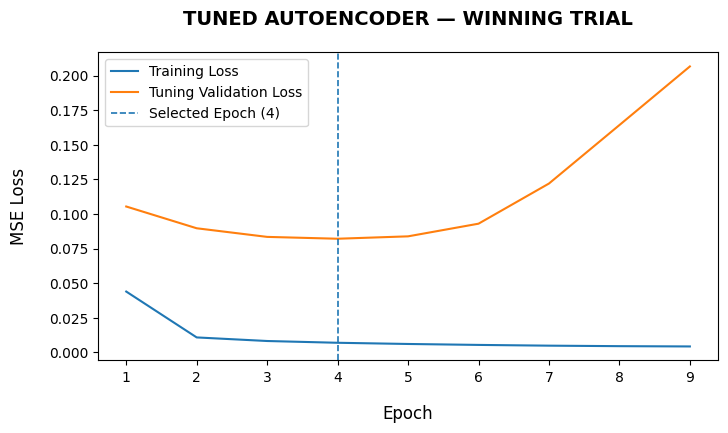

2026-08-18 15:50:04.294955: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



WINNING CONFIGURATION
  Initial learning rate      : 0.001
  Batch size                 : 16
  Best tuning epoch          : 4
  Best tuning validation MSE : 0.082103
  Calibration threshold      : 0.08341378
  Calibration flag rate      : 4.76% (target ≤ 5.00%)

✅ BLOCK 7 COMPLETED: Training configuration selected and threshold calibrated without final-test access.


In [7]:
# ==========================================================================================================================================================
# BLOCK 7: CONTROLLED HYPERPARAMETER TUNING & THRESHOLD CALIBRATION
# ==========================================================================================================================================================

print("EXECUTING CONTROLLED AUTOENCODER TUNING...\n")
print("ACTION: Separating tuning and calibration roles, evaluating the fixed grid and freezing the winning configuration.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_7_objects = [
    "train_images",
    "validation_images",
    "build_tuned_autoencoder",
    "LEARNING_RATE_GRID",
    "BATCH_SIZE_GRID",
    "MAX_TUNING_EPOCHS",
    "EARLY_STOPPING_PATIENCE",
    "LR_REDUCTION_PATIENCE",
    "LR_REDUCTION_FACTOR",
    "MIN_LEARNING_RATE",
    "TUNING_VALIDATION_FRACTION",
    "TARGET_VALIDATION_FPR",
    "TUNING_TEMP_ROOT",
    "SEED",
]

_missing_block_7_objects = [
    object_name
    for object_name in _required_block_7_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_7_objects:
    raise RuntimeError(
        "BLOCK 7 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_7_objects}. Run the notebook sequentially from Block 1."
    )


# DEVELOPMENT VALIDATION PARTITION

validation_pool_indices = np.arange(
    len(
        validation_images
    )
)

tuning_validation_indices, calibration_indices = train_test_split(
    validation_pool_indices,
    test_size=1.0 - TUNING_VALIDATION_FRACTION,
    random_state=SEED,
    shuffle=True,
)

tuning_validation_images = validation_images[
    tuning_validation_indices
]

calibration_images = validation_images[
    calibration_indices
]


if (
    len(
        tuning_validation_images
    ) == 0
    or len(
        calibration_images
    ) == 0
):
    raise RuntimeError(
        "BLOCK 7 SPLIT FAILURE: tuning-validation and calibration subsets must both be non-empty."
    )


if set(
    tuning_validation_indices.tolist()
).intersection(
    calibration_indices.tolist()
):
    raise RuntimeError(
        "BLOCK 7 SPLIT FAILURE: tuning-validation and calibration indices overlap."
    )


development_partition_df = pd.DataFrame(
    [
        {
            "data_object": "train_images",
            "role": "candidate-model fitting",
            "samples": len(
                train_images
            ),
        },
        {
            "data_object": "tuning_validation_images",
            "role": "early stopping / LR scheduling / hyperparameter selection",
            "samples": len(
                tuning_validation_images
            ),
        },
        {
            "data_object": "calibration_images",
            "role": "independent normal threshold calibration",
            "samples": len(
                calibration_images
            ),
        },
    ]
)

print(
    "DEVELOPMENT PARTITION AUDIT"
)

display(
    development_partition_df
)


# SHARED SCORE / THRESHOLD HELPERS

def reconstruction_mse(
    images,
    reconstructions,
):
    """Return one scalar reconstruction-MSE anomaly score per image."""

    if images.shape != reconstructions.shape:
        raise ValueError(
            "Reconstruction shape mismatch: "
            f"input={images.shape}, output={reconstructions.shape}"
        )

    scores = np.mean(
        np.square(
            images
            - reconstructions
        ),
        axis=(
            1,
            2,
            3,
        ),
    )

    if not np.isfinite(
        scores
    ).all():
        raise ValueError(
            "Non-finite reconstruction anomaly scores detected."
        )

    return scores


def calibrate_normal_threshold(
    normal_scores,
    target_fpr,
):
    """Calibrate a finite-sample upper-tail threshold using normal scores only."""

    normal_scores = np.asarray(
        normal_scores,
        dtype=float,
    ).reshape(
        -1
    )

    if normal_scores.size == 0:
        raise ValueError(
            "Threshold calibration requires at least one normal score."
        )

    if not np.isfinite(
        normal_scores
    ).all():
        raise ValueError(
            "Threshold calibration received non-finite scores."
        )

    if not (
        0.0
        < target_fpr
        < 1.0
    ):
        raise ValueError(
            "target_fpr must be strictly between 0 and 1."
        )

    threshold = float(
        np.quantile(
            normal_scores,
            1.0
            - target_fpr,
            method="higher",
        )
    )

    observed_flag_rate = float(
        np.mean(
            normal_scores
            > threshold
        )
    )

    return (
        threshold,
        observed_flag_rate,
    )


# TEMPORARY TUNING CHECKPOINT
# Stored under /kaggle/temp so it cannot become a persistent Notebook 2 artifact.

TUNING_TEMP_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_TUNING_CHECKPOINT_PATH = (
    TUNING_TEMP_ROOT
    / "best_tuning_checkpoint.keras"
)


# EXHAUSTIVE SMALL-GRID SEARCH

trial_rows = []

best_validation_loss = np.inf
best_params = None
best_history_data = None
best_epoch = None

trial_number = 0

total_trials = (
    len(
        LEARNING_RATE_GRID
    )
    * len(
        BATCH_SIZE_GRID
    )
)


for learning_rate in LEARNING_RATE_GRID:

    for batch_size in BATCH_SIZE_GRID:

        trial_number += 1


        print(
            f"TRIAL {trial_number}/{total_trials} "
            f"| initial_lr={learning_rate:g} "
            f"| batch_size={batch_size}"
        )


        tf.keras.backend.clear_session()

        tf.keras.utils.set_random_seed(
            SEED
        )


        candidate_model = build_tuned_autoencoder(
            learning_rate=learning_rate
        )


        callbacks = [
            EarlyStopping(
                monitor="val_loss",
                mode="min",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=True,
                verbose=0,
            ),
            ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=LR_REDUCTION_FACTOR,
                patience=LR_REDUCTION_PATIENCE,
                min_lr=MIN_LEARNING_RATE,
                verbose=0,
            ),
        ]


        history = candidate_model.fit(
            train_images,
            train_images,
            validation_data=(
                tuning_validation_images,
                tuning_validation_images,
            ),
            epochs=MAX_TUNING_EPOCHS,
            batch_size=batch_size,
            shuffle=True,
            callbacks=callbacks,
            verbose=0,
        )


        train_loss = np.asarray(
            history.history[
                "loss"
            ],
            dtype=float,
        )

        validation_loss = np.asarray(
            history.history[
                "val_loss"
            ],
            dtype=float,
        )


        if (
            len(
                train_loss
            ) == 0
            or len(
                validation_loss
            ) == 0
            or not np.isfinite(
                train_loss
            ).all()
            or not np.isfinite(
                validation_loss
            ).all()
        ):
            raise RuntimeError(
                f"BLOCK 7 TUNING FAILURE: invalid loss history in trial {trial_number}."
            )


        trial_best_epoch = int(
            np.argmin(
                validation_loss
            )
        ) + 1


        trial_best_validation_loss = float(
            np.min(
                validation_loss
            )
        )


        final_learning_rate = float(
            tf.keras.backend.get_value(
                candidate_model.optimizer.learning_rate
            )
        )


        trial_rows.append(
            {
                "trial": trial_number,
                "initial_learning_rate": float(
                    learning_rate
                ),
                "batch_size": int(
                    batch_size
                ),
                "epochs_ran": int(
                    len(
                        validation_loss
                    )
                ),
                "best_epoch": trial_best_epoch,
                "best_validation_mse": trial_best_validation_loss,
                "final_learning_rate": final_learning_rate,
            }
        )


        print(
            f"  best_epoch={trial_best_epoch} "
            f"| best_val_mse={trial_best_validation_loss:.6f} "
            f"| final_lr={final_learning_rate:.6g}"
        )


        if trial_best_validation_loss < best_validation_loss:

            best_validation_loss = trial_best_validation_loss

            best_params = {
                "initial_learning_rate": float(
                    learning_rate
                ),
                "batch_size": int(
                    batch_size
                ),
            }

            best_epoch = trial_best_epoch

            best_history_data = {
                "loss": train_loss.tolist(),
                "val_loss": validation_loss.tolist(),
            }

            candidate_model.save(
                BEST_TUNING_CHECKPOINT_PATH
            )


        del candidate_model
        gc.collect()


# TUNING RESULTS

tuning_results_df = pd.DataFrame(
    trial_rows
).sort_values(
    [
        "best_validation_mse",
        "trial",
    ],
    ascending=[
        True,
        True,
    ],
).reset_index(
    drop=True
)


print(
    "\nTUNING RESULTS"
)

display(
    tuning_results_df
)


if (
    best_params is None
    or best_history_data is None
    or best_epoch is None
    or not BEST_TUNING_CHECKPOINT_PATH.is_file()
):
    raise RuntimeError(
        "BLOCK 7 TUNING FAILURE: no valid winning model was persisted."
    )


# LOAD THE FROZEN WINNING MODEL

tuned_model = tf.keras.models.load_model(
    BEST_TUNING_CHECKPOINT_PATH
)


# WINNING-TRIAL LEARNING CURVE

best_train_loss = np.asarray(
    best_history_data[
        "loss"
    ],
    dtype=float,
)

best_tuning_loss = np.asarray(
    best_history_data[
        "val_loss"
    ],
    dtype=float,
)


plt.figure(
    figsize=(
        8,
        4,
    )
)

plt.plot(
    np.arange(
        1,
        len(
            best_train_loss
        ) + 1,
    ),
    best_train_loss,
    label="Training Loss",
)

plt.plot(
    np.arange(
        1,
        len(
            best_tuning_loss
        ) + 1,
    ),
    best_tuning_loss,
    label="Tuning Validation Loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.2,
    label=f"Selected Epoch ({best_epoch})",
)

plt.title(
    "TUNED AUTOENCODER — WINNING TRIAL",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Epoch",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "MSE Loss",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


# INDEPENDENT NORMAL THRESHOLD CALIBRATION

calibration_reconstructions = tuned_model.predict(
    calibration_images,
    batch_size=best_params[
        "batch_size"
    ],
    verbose=0,
)

tuned_calibration_scores = reconstruction_mse(
    calibration_images,
    calibration_reconstructions,
)

tuned_threshold, tuned_calibration_flag_rate = calibrate_normal_threshold(
    tuned_calibration_scores,
    TARGET_VALIDATION_FPR,
)


print(
    "\nWINNING CONFIGURATION"
)

print(
    f"  Initial learning rate      : {best_params['initial_learning_rate']}"
)

print(
    f"  Batch size                 : {best_params['batch_size']}"
)

print(
    f"  Best tuning epoch          : {best_epoch}"
)

print(
    f"  Best tuning validation MSE : {best_validation_loss:.6f}"
)

print(
    f"  Calibration threshold      : {tuned_threshold:.8f}"
)

print(
    f"  Calibration flag rate      : {tuned_calibration_flag_rate:.2%} "
    f"(target ≤ {TARGET_VALIDATION_FPR:.2%})"
)

print(
    "\n✅ BLOCK 7 COMPLETED: Training configuration selected and threshold calibrated without final-test access."
)


### BLOCK 8: FINAL TEST EVALUATION & QUALITATIVE RESIDUAL ANALYSIS

**OBJECTIVE:**  
Evaluate the frozen tuned autoencoder once on the final MVTec test set.

**QUANTITATIVE EVALUATION:**
- ROC-AUC from continuous reconstruction-MSE anomaly scores;
- balanced accuracy, precision, recall, F1 and test false-positive rate at the independently calibrated threshold;
- descriptive normal-vs-anomaly score statistics;
- per-defect ROC-AUC and detection rate using the same fixed threshold.

**RANKING DIAGNOSTIC:**  
If ROC-AUC falls below `0.5`, the notebook explicitly records the observed ranking inversion. The predefined score direction is **not reversed after seeing the test set**.

**VISUAL ANALYSIS:**
- normalized reconstruction-error distributions for normal and anomalous test images;
- tuned-model ROC curve;
- one representative residual analysis per defect category using a common robust residual scale.

No final-test result is used to modify the model, hyperparameters, score direction or threshold.


OPENING FINAL TEST EVALUATION...

ACTION: Evaluating the frozen tuned autoencoder with the independently calibrated threshold.

TUNED MODEL — FINAL TEST METRICS


,roc_auc,threshold,balanced_accuracy,precision,recall,f1,test_false_positive_rate,tn,fp,fn,tp
model,,,,,,,,,,,
Tuned Conv AE,0.336508,0.083414,0.52381,1.0,0.047619,0.090909,0.0,20,0,60,3



FINAL TEST SCORE DIAGNOSTIC


,group,samples,mean_score,median_score,std_score,min_score,max_score
0,Normal (Test),20,0.082200,0.082321,0.000615,0.08074,0.083104
1,Anomaly (Test),63,0.081421,0.081717,0.001550,0.07558,0.083870



⚠️ RANKING DIAGNOSTIC: ROC-AUC is below 0.5. Under the predefined contract 'higher reconstruction error = more anomalous', the tuned model ranks many anomalous samples below normal samples. The score direction is intentionally NOT reversed after observing the final test set.


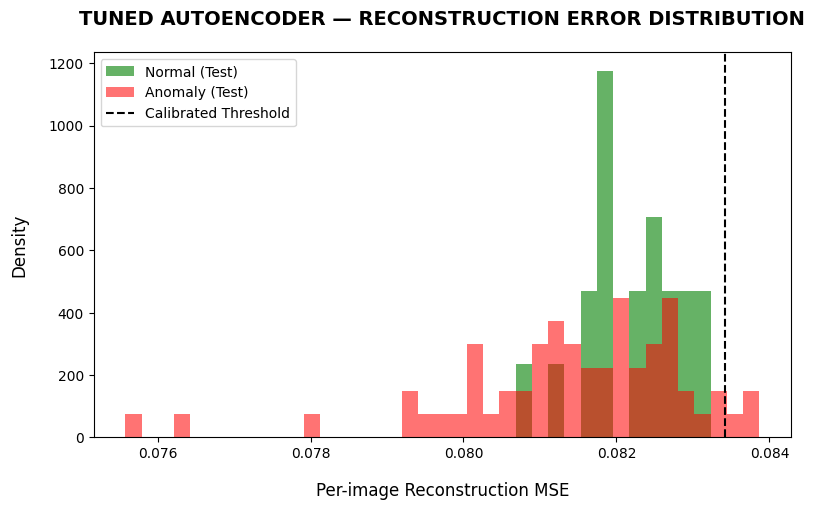

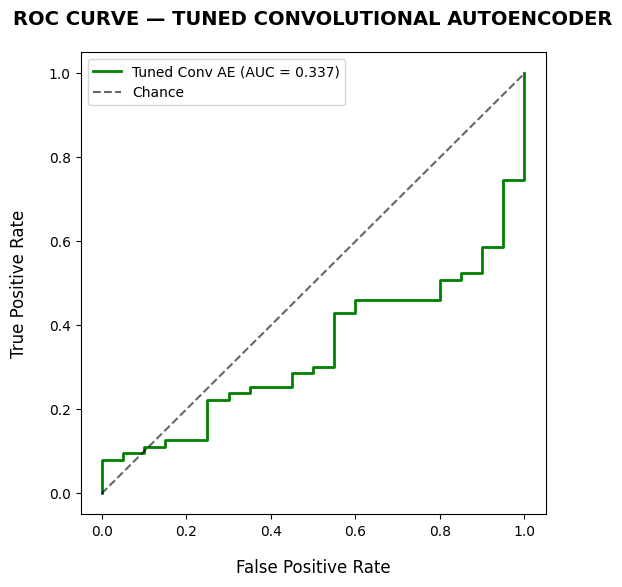


TUNED MODEL — PER-DEFECT FINAL TEST ANALYSIS


,defect_category,defect_samples,roc_auc_vs_good,detection_rate_at_threshold
0,broken_large,20,0.252500,0.050000
1,broken_small,22,0.520455,0.045455
2,contamination,21,0.223810,0.047619


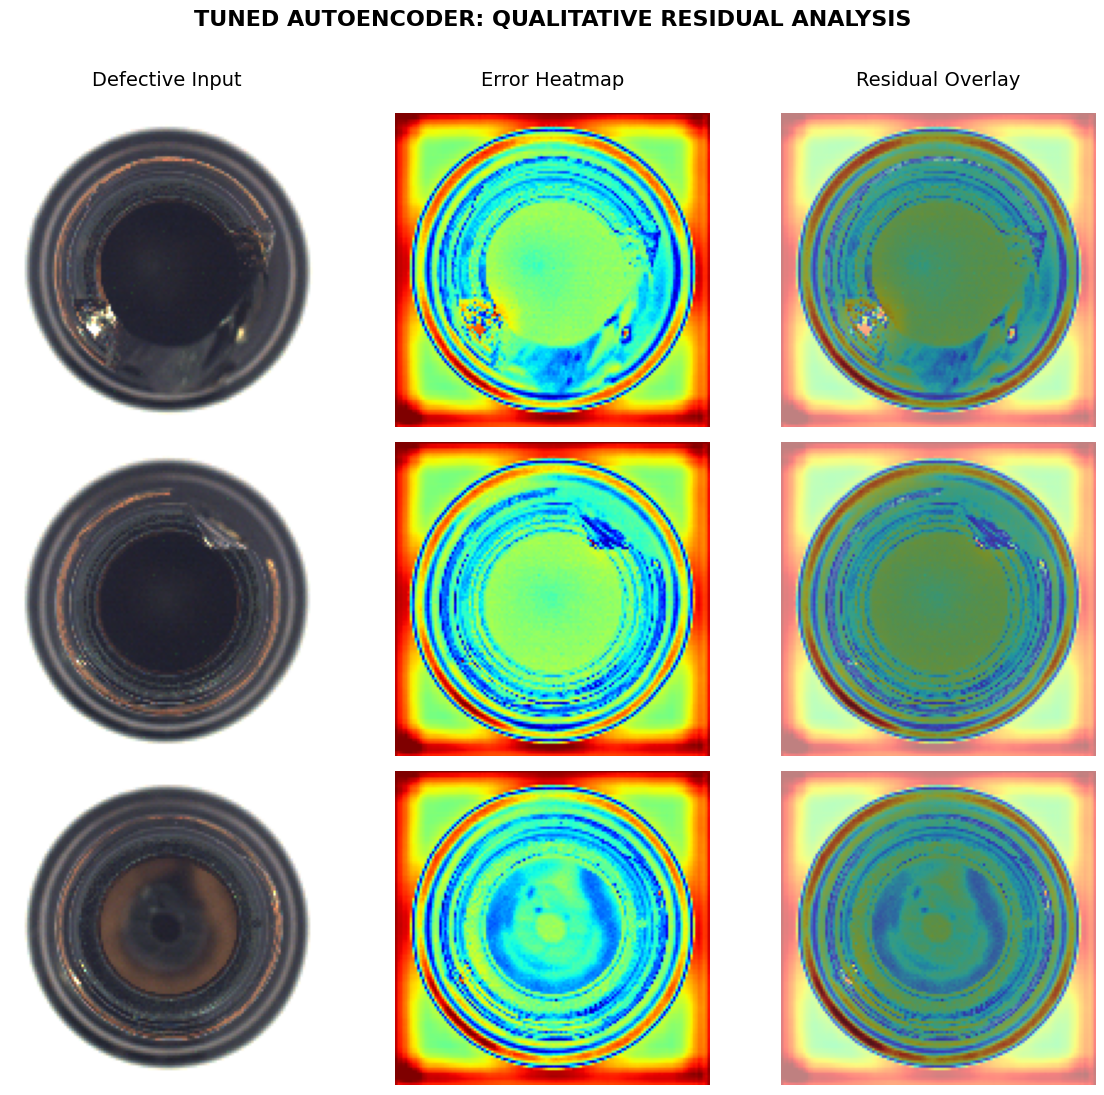


NOTE: Residual maps use one shared 99th-percentile intensity scale across defect categories. They are qualitative reconstruction-error visualizations, not proof of pixel-accurate localization.

✅ BLOCK 8 COMPLETED: Frozen tuned model evaluated once on the final test set.


In [8]:
# ==========================================================================================================================================================
# BLOCK 8: FINAL TEST EVALUATION & QUALITATIVE RESIDUAL ANALYSIS
# ==========================================================================================================================================================

print("OPENING FINAL TEST EVALUATION...\n")
print("ACTION: Evaluating the frozen tuned autoencoder with the independently calibrated threshold.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_8_objects = [
    "tuned_model",
    "tuned_threshold",
    "test_images",
    "test_labels",
    "test_categories",
    "test_good",
    "test_bad",
    "test_bad_categories",
    "defect_categories",
    "reconstruction_mse",
    "NORMAL_LABEL",
    "ANOMALY_LABEL",
    "best_params",
    "SEED",
]

_missing_block_8_objects = [
    object_name
    for object_name in _required_block_8_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_8_objects:
    raise RuntimeError(
        "BLOCK 8 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_8_objects}. Run the notebook sequentially from Block 1."
    )


def compute_operational_metrics(
    y_true,
    anomaly_scores,
    threshold,
):
    """Compute binary operating metrics under the shared 0=good, 1=anomaly contract."""

    predictions = (
        anomaly_scores
        > threshold
    ).astype(
        np.int8
    )


    matrix = confusion_matrix(
        y_true,
        predictions,
        labels=[
            NORMAL_LABEL,
            ANOMALY_LABEL,
        ],
    )


    tn, fp, fn, tp = matrix.ravel()


    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        predictions,
        average="binary",
        pos_label=ANOMALY_LABEL,
        zero_division=0,
    )


    false_positive_rate = fp / max(
        fp + tn,
        1,
    )


    return {
        "roc_auc": float(
            roc_auc_score(
                y_true,
                anomaly_scores,
            )
        ),
        "threshold": float(
            threshold
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                predictions,
            )
        ),
        "precision": float(
            precision
        ),
        "recall": float(
            recall
        ),
        "f1": float(
            f1
        ),
        "test_false_positive_rate": float(
            false_positive_rate
        ),
        "tn": int(
            tn
        ),
        "fp": int(
            fp
        ),
        "fn": int(
            fn
        ),
        "tp": int(
            tp
        ),
    }


# FINAL TEST RECONSTRUCTION & CONTINUOUS ANOMALY SCORES

test_reconstructions = tuned_model.predict(
    test_images,
    batch_size=best_params[
        "batch_size"
    ],
    verbose=0,
)

tuned_test_scores = reconstruction_mse(
    test_images,
    test_reconstructions,
)

tuned_metrics = compute_operational_metrics(
    test_labels,
    tuned_test_scores,
    tuned_threshold,
)

tuned_auc = tuned_metrics[
    "roc_auc"
]

tuned_fpr, tuned_tpr, _ = roc_curve(
    test_labels,
    tuned_test_scores,
)


tuned_metrics_df = pd.DataFrame(
    [
        {
            "model": "Tuned Conv AE",
            **tuned_metrics,
        }
    ]
).set_index(
    "model"
)


print(
    "TUNED MODEL — FINAL TEST METRICS"
)

display(
    tuned_metrics_df
)


# TEST-SCORE DIAGNOSTIC

good_mask = (
    test_labels
    == NORMAL_LABEL
)

anomaly_mask = (
    test_labels
    == ANOMALY_LABEL
)

good_scores = tuned_test_scores[
    good_mask
]

bad_scores = tuned_test_scores[
    anomaly_mask
]


score_summary_df = pd.DataFrame(
    [
        {
            "group": "Normal (Test)",
            "samples": int(
                len(
                    good_scores
                )
            ),
            "mean_score": float(
                np.mean(
                    good_scores
                )
            ),
            "median_score": float(
                np.median(
                    good_scores
                )
            ),
            "std_score": float(
                np.std(
                    good_scores
                )
            ),
            "min_score": float(
                np.min(
                    good_scores
                )
            ),
            "max_score": float(
                np.max(
                    good_scores
                )
            ),
        },
        {
            "group": "Anomaly (Test)",
            "samples": int(
                len(
                    bad_scores
                )
            ),
            "mean_score": float(
                np.mean(
                    bad_scores
                )
            ),
            "median_score": float(
                np.median(
                    bad_scores
                )
            ),
            "std_score": float(
                np.std(
                    bad_scores
                )
            ),
            "min_score": float(
                np.min(
                    bad_scores
                )
            ),
            "max_score": float(
                np.max(
                    bad_scores
                )
            ),
        },
    ]
)


print(
    "\nFINAL TEST SCORE DIAGNOSTIC"
)

display(
    score_summary_df
)


ranking_inversion_observed = bool(
    tuned_auc
    < 0.5
)


if ranking_inversion_observed:

    print(
        "\n⚠️ RANKING DIAGNOSTIC: ROC-AUC is below 0.5. "
        "Under the predefined contract 'higher reconstruction error = more anomalous', "
        "the tuned model ranks many anomalous samples below normal samples. "
        "The score direction is intentionally NOT reversed after observing the final test set."
    )

else:

    print(
        "\nRANKING DIAGNOSTIC: No below-chance ranking inversion was observed under the predefined score direction."
    )


# RECONSTRUCTION-ERROR DISTRIBUTION
# Density normalization makes the 20 normal and 63 anomalous samples directly comparable.

score_min = float(
    min(
        good_scores.min(),
        bad_scores.min(),
    )
)

score_max = float(
    max(
        good_scores.max(),
        bad_scores.max(),
    )
)

score_bins = np.linspace(
    score_min,
    score_max,
    40,
)


plt.figure(
    figsize=(
        9,
        5,
    )
)

plt.hist(
    good_scores,
    bins=score_bins,
    density=True,
    alpha=0.60,
    color="green",
    label="Normal (Test)",
)

plt.hist(
    bad_scores,
    bins=score_bins,
    density=True,
    alpha=0.55,
    color="red",
    label="Anomaly (Test)",
)

plt.axvline(
    tuned_threshold,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Calibrated Threshold",
)

plt.title(
    "TUNED AUTOENCODER — RECONSTRUCTION ERROR DISTRIBUTION",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Per-image Reconstruction MSE",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "Density",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


# TUNED MODEL ROC

plt.figure(
    figsize=(
        6,
        6,
    )
)

plt.plot(
    tuned_fpr,
    tuned_tpr,
    color="green",
    linewidth=2,
    label=f"Tuned Conv AE (AUC = {tuned_auc:.3f})",
)

plt.plot(
    [
        0,
        1,
    ],
    [
        0,
        1,
    ],
    linestyle="--",
    color="black",
    alpha=0.6,
    label="Chance",
)

plt.title(
    "ROC CURVE — TUNED CONVOLUTIONAL AUTOENCODER",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    labelpad=15,
)

plt.legend()
plt.show()


# PER-DEFECT ANALYSIS

def build_per_defect_report(
    scores,
    threshold,
):
    """Compare each defect category against the common good-test reference subset."""

    report_rows = []

    reference_good_scores = scores[
        test_categories
        == "good"
    ]


    for category in defect_categories:

        defect_scores = scores[
            test_categories
            == category
        ]


        category_labels = np.concatenate(
            (
                np.full(
                    len(
                        reference_good_scores
                    ),
                    NORMAL_LABEL,
                    dtype=np.int8,
                ),
                np.full(
                    len(
                        defect_scores
                    ),
                    ANOMALY_LABEL,
                    dtype=np.int8,
                ),
            )
        )


        category_scores = np.concatenate(
            (
                reference_good_scores,
                defect_scores,
            )
        )


        report_rows.append(
            {
                "defect_category": category,
                "defect_samples": int(
                    len(
                        defect_scores
                    )
                ),
                "roc_auc_vs_good": float(
                    roc_auc_score(
                        category_labels,
                        category_scores,
                    )
                ),
                "detection_rate_at_threshold": float(
                    np.mean(
                        defect_scores
                        > threshold
                    )
                ),
            }
        )


    return report_rows


tuned_per_defect_metrics = pd.DataFrame(
    build_per_defect_report(
        tuned_test_scores,
        tuned_threshold,
    )
)


print(
    "\nTUNED MODEL — PER-DEFECT FINAL TEST ANALYSIS"
)

display(
    tuned_per_defect_metrics
)


# QUALITATIVE RECONSTRUCTION-RESIDUAL ANALYSIS

bad_reconstructions = test_reconstructions[
    anomaly_mask
]


if len(
    bad_reconstructions
) != len(
    test_bad
):
    raise RuntimeError(
        "BLOCK 8 ALIGNMENT FAILURE: anomalous reconstructions are misaligned."
    )


def compute_residual_map(
    original,
    reconstructed,
):
    """Return the channel-averaged absolute reconstruction residual."""

    residual_map = np.mean(
        np.abs(
            original
            - reconstructed
        ),
        axis=-1,
    )

    if not np.isfinite(
        residual_map
    ).all():
        raise RuntimeError(
            "BLOCK 8 RESIDUAL FAILURE: non-finite residual values detected."
        )

    return residual_map


representative_indices = []

rng_residual = np.random.default_rng(
    SEED
    + 20
)


for category in defect_categories:

    category_indices = np.flatnonzero(
        test_bad_categories
        == category
    )

    if len(
        category_indices
    ) == 0:
        continue

    representative_indices.append(
        int(
            rng_residual.choice(
                category_indices
            )
        )
    )


if not representative_indices:
    raise RuntimeError(
        "BLOCK 8 RESIDUAL FAILURE: no anomalous samples available."
    )


selected_residual_maps = [
    compute_residual_map(
        test_bad[
            index
        ],
        bad_reconstructions[
            index
        ],
    )
    for index in representative_indices
]


shared_vmax = float(
    np.quantile(
        np.concatenate(
            [
                residual_map.ravel()
                for residual_map in selected_residual_maps
            ]
        ),
        0.99,
    )
)

shared_vmax = max(
    shared_vmax,
    np.finfo(
        np.float32
    ).eps,
)


n_show = len(
    representative_indices
)


plt.figure(
    figsize=(
        12,
        3.6
        * n_show,
    )
)

plt.suptitle(
    "TUNED AUTOENCODER: QUALITATIVE RESIDUAL ANALYSIS",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)


for row_index, sample_index in enumerate(
    representative_indices
):

    original = test_bad[
        sample_index
    ]

    residual_map = selected_residual_maps[
        row_index
    ]

    category_label = str(
        test_bad_categories[
            sample_index
        ]
    ).replace(
        "_",
        " ",
    ).title()


    ax = plt.subplot(
        n_show,
        3,
        row_index
        * 3
        + 1,
    )

    ax.imshow(
        original
    )

    if row_index == 0:

        ax.set_title(
            "Defective Input",
            fontsize=14,
            pad=20,
        )

    ax.set_ylabel(
        category_label,
        fontsize=11,
        labelpad=12,
    )

    ax.axis(
        "off"
    )


    ax = plt.subplot(
        n_show,
        3,
        row_index
        * 3
        + 2,
    )

    ax.imshow(
        residual_map,
        cmap="jet",
        vmin=0.0,
        vmax=shared_vmax,
    )

    if row_index == 0:

        ax.set_title(
            "Error Heatmap",
            fontsize=14,
            pad=20,
        )

    ax.axis(
        "off"
    )


    ax = plt.subplot(
        n_show,
        3,
        row_index
        * 3
        + 3,
    )

    ax.imshow(
        original
    )

    ax.imshow(
        residual_map,
        cmap="jet",
        alpha=0.50,
        vmin=0.0,
        vmax=shared_vmax,
    )

    if row_index == 0:

        ax.set_title(
            "Residual Overlay",
            fontsize=14,
            pad=20,
        )

    ax.axis(
        "off"
    )


plt.tight_layout()
plt.show()


print(
    "\nNOTE: Residual maps use one shared 99th-percentile intensity scale across defect categories. "
    "They are qualitative reconstruction-error visualizations, not proof of pixel-accurate localization."
)

print(
    "\n✅ BLOCK 8 COMPLETED: Frozen tuned model evaluated once on the final test set."
)


### BLOCK 9: CONTROLLED COMPARISON & SCIENTIFIC CONCLUSION

**OBJECTIVE:**  
Compare the tuned convolutional autoencoder against the frozen Notebook 1 baselines using the common final-test ROC-AUC metric.

**COMPARISON RULES:**
- Notebook 1 values are imported from its validated metrics contract.
- Notebook 2 contributes only the tuned-model result generated in Block 8.
- Numerical differences are interpreted descriptively; no statistical-significance claim is made from one fixed test set.
- A below-chance tuned-model ROC-AUC is reported as a ranking failure under the predefined score direction, not repaired by post-hoc score inversion.

This block answers one controlled question: **did the Notebook 2 tuning experiment improve the Simple Autoencoder baseline under the locked evaluation protocol?**


ASSEMBLING CONTROLLED MODEL COMPARISON...

ACTION: Comparing frozen Notebook 1 baselines against the tuned Notebook 2 autoencoder.



,model,source,roc_auc,delta_vs_simple_ae
0,SVM + PCA,Notebook 1,0.561905,0.017460
1,Simple AE,Notebook 1,0.544444,0.000000
2,Tuned Conv AE,Notebook 2,0.336508,-0.207937


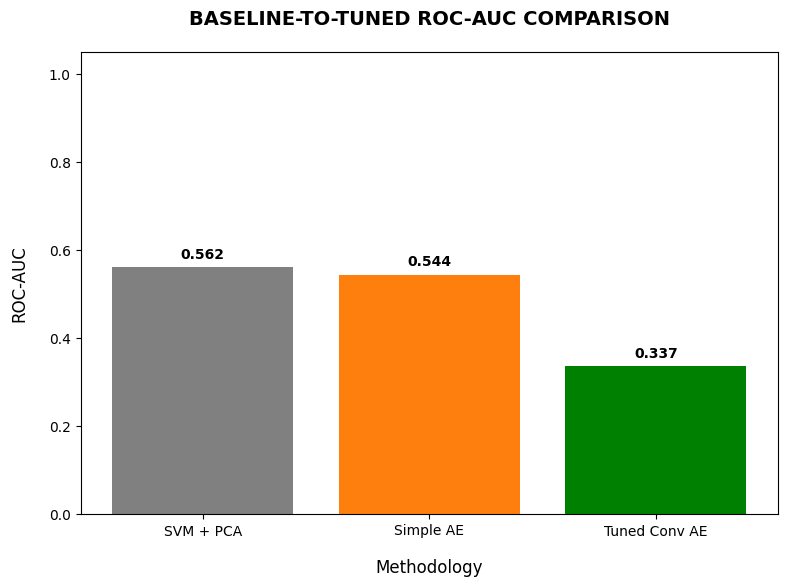

SCIENTIFIC CONCLUSION
The tuned convolutional autoencoder achieved a numerically lower ROC-AUC than the Simple AE baseline by 0.2079. The controlled tuning experiment therefore did not improve the primary anomaly-ranking metric. This negative result is retained rather than using the final test set to redesign the model.
Additional diagnostic: the tuned model produced below-chance ROC-AUC under the locked 'higher reconstruction error = more anomalous' score contract. This indicates test-set ranking inversion and is reported without post-hoc score reversal.

✅ BLOCK 9 COMPLETED: Controlled cross-notebook comparison finalized.


In [9]:
# ==========================================================================================================================================================
# BLOCK 9: CONTROLLED COMPARISON & SCIENTIFIC CONCLUSION
# ==========================================================================================================================================================

print("ASSEMBLING CONTROLLED MODEL COMPARISON...\n")
print("ACTION: Comparing frozen Notebook 1 baselines against the tuned Notebook 2 autoencoder.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_9_objects = [
    "baseline_svm_auc",
    "baseline_ae_auc",
    "tuned_auc",
    "ranking_inversion_observed",
]

_missing_block_9_objects = [
    object_name
    for object_name in _required_block_9_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_9_objects:
    raise RuntimeError(
        "BLOCK 9 DEPENDENCY FAILURE: missing upstream metrics: "
        f"{_missing_block_9_objects}. Run Blocks 5 and 8 first."
    )


comparison_df = pd.DataFrame(
    [
        {
            "model": "SVM + PCA",
            "source": "Notebook 1",
            "roc_auc": baseline_svm_auc,
        },
        {
            "model": "Simple AE",
            "source": "Notebook 1",
            "roc_auc": baseline_ae_auc,
        },
        {
            "model": "Tuned Conv AE",
            "source": "Notebook 2",
            "roc_auc": tuned_auc,
        },
    ]
)


comparison_df[
    "delta_vs_simple_ae"
] = (
    comparison_df[
        "roc_auc"
    ]
    - baseline_ae_auc
)


display(
    comparison_df
)


# PERFORMANCE COMPARISON

models = [
    "SVM + PCA",
    "Simple AE",
    "Tuned Conv AE",
]

scores = [
    baseline_svm_auc,
    baseline_ae_auc,
    tuned_auc,
]

colors = [
    "grey",
    "#ff7f0e",
    "green",
]


plt.figure(
    figsize=(
        9,
        6,
    )
)

bars = plt.bar(
    models,
    scores,
    color=colors,
)

plt.title(
    "BASELINE-TO-TUNED ROC-AUC COMPARISON",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.xlabel(
    "Methodology",
    fontsize=12,
    labelpad=15,
)

plt.ylabel(
    "ROC-AUC",
    fontsize=12,
    labelpad=15,
)

plt.ylim(
    0.0,
    1.05,
)


for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x()
        + bar.get_width()
        / 2,
        value
        + 0.02,
        f"{value:.3f}",
        ha="center",
        fontweight="bold",
    )


plt.show()


# EXPERIMENT-SCOPED CONCLUSION

tuned_delta = (
    tuned_auc
    - baseline_ae_auc
)


print(
    "SCIENTIFIC CONCLUSION"
)


if np.isclose(
    tuned_delta,
    0.0,
    atol=1e-6,
):

    conclusion = (
        "The tuned convolutional autoencoder matched the Simple AE baseline ROC-AUC "
        "within numerical precision in this fixed experiment."
    )


elif tuned_delta > 0.0:

    conclusion = (
        f"The tuned convolutional autoencoder achieved a numerically higher ROC-AUC "
        f"than the Simple AE baseline by {tuned_delta:.4f}. "
        "This supports the value of the controlled Notebook 2 tuning experiment for this dataset, "
        "while the single fixed test set does not by itself establish statistical superiority."
    )


else:

    conclusion = (
        f"The tuned convolutional autoencoder achieved a numerically lower ROC-AUC "
        f"than the Simple AE baseline by {abs(tuned_delta):.4f}. "
        "The controlled tuning experiment therefore did not improve the primary anomaly-ranking metric. "
        "This negative result is retained rather than using the final test set to redesign the model."
    )


print(
    conclusion
)


if ranking_inversion_observed:

    print(
        "Additional diagnostic: the tuned model produced below-chance ROC-AUC under the locked "
        "'higher reconstruction error = more anomalous' score contract. "
        "This indicates test-set ranking inversion and is reported without post-hoc score reversal."
    )


print(
    "\n✅ BLOCK 9 COMPLETED: Controlled cross-notebook comparison finalized."
)


### BLOCK 10: TUNED MODEL & METRIC EXPORT

**OBJECTIVE:**  
Persist the Notebook 2 tuning result, evaluation evidence and cross-notebook metadata for later thesis comparison and deployment work.

**EXPORTED ARTIFACTS:**
- tuned convolutional autoencoder (`.keras`);
- complete tuning-results table (`.csv`);
- final-test score summary (`.csv`);
- per-defect evaluation (`.csv`);
- Notebook 2 experiment contract (`notebook2_metrics.json`).

**CROSS-NOTEBOOK CONTRACT:**  
The top-level key `conv_ae` exposes the Notebook 2 ROC-AUC using the canonical comparison name required by later notebooks.

Temporary tuning checkpoints and extracted raw data remain under `/kaggle/temp` and are not treated as persistent thesis artifacts.


In [10]:
# ==========================================================================================================================================================
# BLOCK 10: TUNED MODEL & METRIC EXPORT
# ==========================================================================================================================================================

print("EXPORTING NOTEBOOK 2 TUNING ARTIFACTS...\n")
print("ACTION: Persisting the tuned model, tuning evidence, diagnostic summaries and cross-notebook metric contract.\n")


# UPSTREAM DEPENDENCY AUDIT

_required_block_10_objects = [
    "tuned_model",
    "tuned_auc",
    "tuned_metrics",
    "tuned_threshold",
    "tuned_calibration_flag_rate",
    "ranking_inversion_observed",
    "score_summary_df",
    "tuned_per_defect_metrics",
    "tuning_results_df",
    "best_params",
    "best_epoch",
    "best_validation_loss",
    "latent_shape",
    "compression_ratio",
    "baseline_svm_auc",
    "baseline_ae_auc",
    "baseline_contract",
    "BASELINE_METRICS_PATH",
    "NOTEBOOK2_ARTIFACT_DIR",
    "NOTEBOOK2_METRICS_PATH",
    "BEST_TUNING_CHECKPOINT_PATH",
    "train_images",
    "validation_images",
    "tuning_validation_images",
    "calibration_images",
    "test_good",
    "test_bad",
    "test_bad_categories",
    "TARGET_CLASS",
    "IMG_SIZE",
    "SEED",
    "TARGET_VALIDATION_FPR",
    "LEARNING_RATE_GRID",
    "BATCH_SIZE_GRID",
    "MAX_TUNING_EPOCHS",
]

_missing_block_10_objects = [
    object_name
    for object_name in _required_block_10_objects
    if object_name not in globals() or globals()[object_name] is None
]

if _missing_block_10_objects:
    raise RuntimeError(
        "BLOCK 10 DEPENDENCY FAILURE: missing upstream objects: "
        f"{_missing_block_10_objects}. Run the notebook sequentially from Block 1."
    )


# ARTIFACT PATHS

NOTEBOOK2_ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TUNED_MODEL_PATH = (
    NOTEBOOK2_ARTIFACT_DIR
    / "tuned_conv_ae.keras"
)

TUNING_RESULTS_PATH = (
    NOTEBOOK2_ARTIFACT_DIR
    / "tuning_results.csv"
)

TEST_SCORE_SUMMARY_PATH = (
    NOTEBOOK2_ARTIFACT_DIR
    / "test_score_summary.csv"
)

PER_DEFECT_METRICS_PATH = (
    NOTEBOOK2_ARTIFACT_DIR
    / "tuned_per_defect_metrics.csv"
)


# ARTIFACT EXPORT

tuned_model.save(
    TUNED_MODEL_PATH
)

tuning_results_df.to_csv(
    TUNING_RESULTS_PATH,
    index=False,
)

score_summary_df.to_csv(
    TEST_SCORE_SUMMARY_PATH,
    index=False,
)

tuned_per_defect_metrics.to_csv(
    PER_DEFECT_METRICS_PATH,
    index=False,
)


# PORTABLE PATH HELPER

def to_portable_relative_path(
    path
):
    """Return a path relative to the directory containing notebook2_metrics.json."""

    path = Path(
        path
    )

    try:

        return path.relative_to(
            NOTEBOOK2_METRICS_PATH.parent
        ).as_posix()

    except ValueError as exc:

        raise RuntimeError(
            "BLOCK 10 PATH FAILURE: exported artifact lies outside the metrics-contract directory: "
            f"{path}"
        ) from exc


# DATASET TRACEABILITY

defect_sample_counts = {
    str(category): int(
        np.sum(
            test_bad_categories
            == category
        )
    )
    for category in sorted(
        np.unique(
            test_bad_categories
        )
    )
}


# RANKING DIAGNOSTIC CONTRACT

normal_score_row = score_summary_df.loc[
    score_summary_df[
        "group"
    ]
    == "Normal (Test)"
].iloc[
    0
]

anomaly_score_row = score_summary_df.loc[
    score_summary_df[
        "group"
    ]
    == "Anomaly (Test)"
].iloc[
    0
]


# NOTEBOOK 2 CROSS-NOTEBOOK CONTRACT

notebook2_metrics = {
    "schema_version": "2.1",

    "experiment_role": "controlled_autoencoder_tuning",

    "target_class": TARGET_CLASS,

    "img_size": list(
        IMG_SIZE
    ),

    "seed": SEED,

    "label_contract": {
        "good": NORMAL_LABEL,
        "anomaly": ANOMALY_LABEL,
    },

    "score_contract": (
        "higher_score_means_more_anomalous"
    ),

    "score_direction_locked_before_test": True,

    # Canonical downstream comparison key.
    "conv_ae": float(
        tuned_auc
    ),

    "baseline_reference": {
        "source_metrics_filename": BASELINE_METRICS_PATH.name,
        "source_schema_version": baseline_contract[
            "schema_version"
        ],
        "svm_pca": float(
            baseline_svm_auc
        ),
        "simple_ae": float(
            baseline_ae_auc
        ),
    },

    "dataset_summary": {
        "train_normal": int(
            len(
                train_images
            )
        ),
        "outer_validation_normal": int(
            len(
                validation_images
            )
        ),
        "tuning_validation_normal": int(
            len(
                tuning_validation_images
            )
        ),
        "calibration_normal": int(
            len(
                calibration_images
            )
        ),
        "test_normal": int(
            len(
                test_good
            )
        ),
        "test_anomaly": int(
            len(
                test_bad
            )
        ),
        "test_defect_categories": defect_sample_counts,
    },

    "architecture": {
        "model_family": "convolutional_autoencoder",
        "batch_normalization": True,
        "latent_shape": list(
            latent_shape
        ),
        "compression_ratio": float(
            compression_ratio
        ),
    },

    "optimization": {
        "selection_metric": "minimum_tuning_validation_mse",
        "learning_rate_grid": [
            float(
                value
            )
            for value in LEARNING_RATE_GRID
        ],
        "batch_size_grid": [
            int(
                value
            )
            for value in BATCH_SIZE_GRID
        ],
        "max_tuning_epochs": int(
            MAX_TUNING_EPOCHS
        ),
        "best_initial_learning_rate": float(
            best_params[
                "initial_learning_rate"
            ]
        ),
        "best_batch_size": int(
            best_params[
                "batch_size"
            ]
        ),
        "best_epoch": int(
            best_epoch
        ),
        "best_tuning_validation_mse": float(
            best_validation_loss
        ),
    },

    "threshold_policy": {
        "source": "independent_normal_calibration_subset",
        "calibration_samples": int(
            len(
                calibration_images
            )
        ),
        "target_validation_false_positive_rate": float(
            TARGET_VALIDATION_FPR
        ),
        "empirical_quantile_method": "higher",
        "decision_rule": "score > threshold",
        "threshold": float(
            tuned_threshold
        ),
        "observed_calibration_flag_rate": float(
            tuned_calibration_flag_rate
        ),
    },

    "model_metrics": {
        **tuned_metrics,
    },

    "ranking_diagnostic": {
        "ranking_inversion_observed": bool(
            ranking_inversion_observed
        ),
        "normal_mean_score": float(
            normal_score_row[
                "mean_score"
            ]
        ),
        "normal_median_score": float(
            normal_score_row[
                "median_score"
            ]
        ),
        "anomaly_mean_score": float(
            anomaly_score_row[
                "mean_score"
            ]
        ),
        "anomaly_median_score": float(
            anomaly_score_row[
                "median_score"
            ]
        ),
        "posthoc_score_reversal_applied": False,
    },

    "artifact_path_policy": (
        "paths_are_relative_to_the_directory_containing_notebook2_metrics_json"
    ),

    "artifacts": {
        "tuned_model": to_portable_relative_path(
            TUNED_MODEL_PATH
        ),
        "tuning_results": to_portable_relative_path(
            TUNING_RESULTS_PATH
        ),
        "test_score_summary": to_portable_relative_path(
            TEST_SCORE_SUMMARY_PATH
        ),
        "per_defect_metrics": to_portable_relative_path(
            PER_DEFECT_METRICS_PATH
        ),
    },
}


# JSON EXPORT

with NOTEBOOK2_METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        notebook2_metrics,
        file,
        indent=2,
        sort_keys=True,
    )


# REMOVE TEMPORARY TUNING CHECKPOINT AFTER FINAL ARTIFACT CREATION

BEST_TUNING_CHECKPOINT_PATH.unlink(
    missing_ok=True
)


# ARTIFACT VERIFICATION

artifact_paths = [
    NOTEBOOK2_METRICS_PATH,
    TUNED_MODEL_PATH,
    TUNING_RESULTS_PATH,
    TEST_SCORE_SUMMARY_PATH,
    PER_DEFECT_METRICS_PATH,
]


artifact_audit = pd.DataFrame(
    [
        {
            "artifact": path.name,
            "exists": path.is_file(),
            "size_kb": (
                round(
                    path.stat().st_size
                    / 1024.0,
                    2,
                )
                if path.is_file()
                else np.nan
            ),
            "portable_path": (
                path.name
                if path
                == NOTEBOOK2_METRICS_PATH
                else to_portable_relative_path(
                    path
                )
            ),
            "runtime_path": str(
                path
            ),
        }
        for path in artifact_paths
    ]
)


if not artifact_audit[
    "exists"
].all():

    missing = artifact_audit.loc[
        ~artifact_audit[
            "exists"
        ],
        "artifact",
    ].tolist()

    raise RuntimeError(
        "BLOCK 10 EXPORT FAILURE: "
        f"missing artifacts: {missing}"
    )


display(
    artifact_audit
)


print(
    f"\nPrimary metrics contract: {NOTEBOOK2_METRICS_PATH}"
)

print(
    "\n✅ BLOCK 10 COMPLETED: Tuned model, tuning evidence, diagnostics and metrics exported successfully."
)


EXPORTING NOTEBOOK 2 TUNING ARTIFACTS...

ACTION: Persisting the tuned model, tuning evidence, diagnostic summaries and cross-notebook metric contract.



,artifact,exists,size_kb,portable_path,runtime_path
0,notebook2_metrics.json,True,2.74,notebook2_metrics.json,/kaggle/working/notebook2_metrics.json
1,tuned_conv_ae.keras,True,4025.91,notebook2_artifacts/tuned_conv_ae.keras,/kaggle/working/notebook2_artifacts/tuned_conv...
2,tuning_results.csv,True,0.32,notebook2_artifacts/tuning_results.csv,/kaggle/working/notebook2_artifacts/tuning_res...
3,test_score_summary.csv,True,0.30,notebook2_artifacts/test_score_summary.csv,/kaggle/working/notebook2_artifacts/test_score...
4,tuned_per_defect_metrics.csv,True,0.21,notebook2_artifacts/tuned_per_defect_metrics.csv,/kaggle/working/notebook2_artifacts/tuned_per_...



Primary metrics contract: /kaggle/working/notebook2_metrics.json

✅ BLOCK 10 COMPLETED: Tuned model, tuning evidence, diagnostics and metrics exported successfully.
